In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# ============= ЭТАП 1: ЗАГРУЗКА ДАННЫХ =============

print("="*50)
print("ЭТАП 1: ЗАГРУЗКА ДАННЫХ")
print("="*50)

# Загрузка справочников
print("\n1. Загрузка справочников...")
subjects = pd.read_csv('Идентификаторы Субъектов 10.04.2025.csv', sep=';')
mo = pd.read_csv('Идентификаторы МО 15.04.2025.csv')

# Загрузка связок
print("2. Загрузка связок пациент-программа...")
patient_program = pd.read_csv('МО и Пациенты 10.04.2025.csv', sep=';')
# Очищаем id пациента от всех видов пробелов
patient_program['id пациента'] = (patient_program['id пациента']
                                  .astype(str)
                                  .str.replace(r'\s+', '', regex=True)  # все пробельные символы
                                  .str.replace('\xa0', '', regex=False)  # неразрывный пробел
                                  .astype(int))
# Загрузка основных данных (с чанками для больших файлов)
print("3. Загрузка первичных данных (может занять время)...")
primary_chunks = []
chunk_size = 500000
for chunk in pd.read_csv('Первичные данные от 10.04.2025.csv', chunksize=chunk_size, sep=','):
    primary_chunks.append(chunk)
primary = pd.concat(primary_chunks, ignore_index=True)

print("4. Загрузка терапии...")
therapy = pd.read_csv('Медикаментозная терапия от 10.04.2025.csv')

print("5. Загрузка КЗС...")
kzs = pd.read_csv('Клинически значимые события от 15.04.2025.csv')

print(f"\nЗагружено:")
print(f"  Субъекты: {len(subjects)} строк")
print(f"  МО: {len(mo)} строк")
print(f"  Пациент-программа: {len(patient_program)} строк")
print(f"  Первичные данные: {len(primary):,} строк")
print(f"  Терапия: {len(therapy):,} строк")
print(f"  КЗС: {len(kzs):,} строк")

ЭТАП 1: ЗАГРУЗКА ДАННЫХ

1. Загрузка справочников...
2. Загрузка связок пациент-программа...
3. Загрузка первичных данных (может занять время)...
4. Загрузка терапии...
5. Загрузка КЗС...

Загружено:
  Субъекты: 19 строк
  МО: 119 строк
  Пациент-программа: 13943 строк
  Первичные данные: 4,888,853 строк
  Терапия: 23,798 строк
  КЗС: 1,243,036 строк


In [45]:
# ============= ЭТАП 2: ПРОВЕРКА ЦЕЛОСТНОСТИ =============

print("\n" + "="*50)
print("ЭТАП 2: ПРОВЕРКА ЦЕЛОСТНОСТИ")
print("="*50)

# Проверка наличия всех ID в справочниках
print("\n1. Проверка целостности связей:")
# Сначала добавляем id субъекта в patient_program по названию
print("Реальные колонки в subjects:", subjects.columns.tolist())
print("Реальные колонки в patient_program:", patient_program.columns.tolist())
patient_program['id пациента'] = patient_program['id пациента'].astype(str).str.replace(' ', '').astype(int)

# Теперь делаем merge с subjects
patient_program = patient_program.merge(
    subjects[['id субъекта', 'название субъекта']],
    on='название субъекта',
    how='left'
)

# Теперь проверяем
mo_in_patient = patient_program['id МО'].isin(mo['id МО']).mean()
print(f"  % id МО из patient_program, присутствующих в справочнике МО: {mo_in_patient*100:.1f}%")

subj_in_patient = patient_program['id субъекта'].notna().mean()
print(f"  % записей с найденным id субъекта: {subj_in_patient*100:.1f}%")

# Дубликаты в ключевых таблицах
print("\n2. Проверка дубликатов:")
print(f"  Дубликаты в subjects: {subjects.duplicated().sum()}")
print(f"  Дубликаты в mo: {mo.duplicated().sum()}")
print(f"  Дубликаты в patient_program: {patient_program.duplicated().sum()}")
print(f"  Дубликаты в primary (id пациента + время измерения): {primary.duplicated(['id пациента', 'время измерения']).sum():,}")

# ============= ЭТАП 3: ОЧИСТКА ДАННЫХ =============

print("\n" + "="*50)
print("ЭТАП 3: ОЧИСТКА ДАННЫХ")
print("="*50)

# 3.1 Работа с пропусками
print("\n1. Пропуски в первичных данных:")
primary_null = primary.isnull().sum()
primary_null_pct = (primary_null / len(primary)) * 100
null_df = pd.DataFrame({'Пропусков': primary_null, '%': primary_null_pct})
print(null_df[null_df['Пропусков'] > 0])

# 3.2 Форматы данных
print("\n2. Конвертация форматов...")
# Дата/время
primary['время измерения'] = pd.to_datetime(primary['время измерения'], errors='coerce')
primary['время сохранения на сервере'] = pd.to_datetime(primary['время сохранения на сервере'], errors='coerce')
primary['дата рождения пациента'] = pd.to_datetime(primary['дата рождения пациента'], errors='coerce')

therapy['дата начала программы'] = pd.to_datetime(therapy['дата начала программы'], errors='coerce')
therapy['дата назначения'] = pd.to_datetime(therapy['дата назначения'], errors='coerce')
therapy['дата начала приема'] = pd.to_datetime(therapy['дата начала приема'], errors='coerce')
therapy['дата окончания приема'] = pd.to_datetime(therapy['дата окончания приема'], errors='coerce')

kzs['дата, время формирования КЗС'] = pd.to_datetime(kzs['дата, время формирования КЗС'], errors='coerce')

# Числовые поля
primary['САД'] = pd.to_numeric(primary['САД'], errors='coerce')
primary['ДАД'] = pd.to_numeric(primary['ДАД'], errors='coerce')
primary['ЧП'] = pd.to_numeric(primary['ЧП'], errors='coerce')
primary['рост'] = pd.to_numeric(primary['рост'], errors='coerce')
primary['масса'] = pd.to_numeric(primary['масса'], errors='coerce')

# Расчет возраста на момент измерения
primary['возраст'] = (primary['время измерения'] - primary['дата рождения пациента']).dt.days / 365.25

print("  Конвертация завершена")

# ============= ЭТАП 4: OUTLIER ANALYSIS =============

print("\n" + "="*50)
print("ЭТАП 4: АНАЛИЗ ВЫБРОСОВ")
print("="*50)

# 4.1 Физиологические границы
print("\n1. Проверка физиологических границ:")

# САД
invalid_sbp = (primary['САД'] < 40) | (primary['САД'] > 250)
print(f"  САД вне нормы (40-250): {invalid_sbp.sum():,} ({invalid_sbp.mean()*100:.2f}%)")

# ДАД
invalid_dbp = (primary['ДАД'] < 30) | (primary['ДАД'] > 150) | (primary['ДАД'] > primary['САД'])
print(f"  ДАД вне нормы (30-150) или >САД: {(invalid_dbp).sum():,} ({invalid_dbp.mean()*100:.2f}%)")

# ЧП
invalid_hr = (primary['ЧП'] < 30) | (primary['ЧП'] > 220)
print(f"  ЧП вне нормы (30-220): {invalid_hr.sum():,} ({invalid_hr.mean()*100:.2f}%)")

# Возраст
invalid_age = (primary['возраст'] < 18) | (primary['возраст'] > 120)
print(f"  Возраст вне нормы (18-120): {invalid_age.sum():,} ({invalid_age.mean()*100:.2f}%)")

# 4.2 Аномалии по времени
print("\n2. Проверка временных аномалий:")

# Будущие измерения
future_meas = primary['время измерения'] > datetime.now()
print(f"  Измерения в будущем: {future_meas.sum():,} ({future_meas.mean()*100:.2f}%)")

# Слишком частые измерения (на одного пациента в день)
primary['date'] = primary['время измерения'].dt.date
patient_daily = primary.groupby(['id пациента', 'date']).size().reset_index(name='n_meas')
freq_meas = patient_daily[patient_daily['n_meas'] > 20]
print(f"  Пациенто-дней с >20 измерений: {len(freq_meas)} ({len(freq_meas)/len(patient_daily)*100:.2f}%)")


ЭТАП 2: ПРОВЕРКА ЦЕЛОСТНОСТИ

1. Проверка целостности связей:
Реальные колонки в subjects: ['id субъекта', 'название субъекта']
Реальные колонки в patient_program: ['название субъекта', 'id МО', 'id программы', 'группа наблюдения', 'id пациента']
  % id МО из patient_program, присутствующих в справочнике МО: 100.0%
  % записей с найденным id субъекта: 100.0%

2. Проверка дубликатов:
  Дубликаты в subjects: 0
  Дубликаты в mo: 0
  Дубликаты в patient_program: 0
  Дубликаты в primary (id пациента + время измерения): 78,817

ЭТАП 3: ОЧИСТКА ДАННЫХ

1. Пропуски в первичных данных:
                           Пропусков          %
код пациента                     461   0.009430
рост                         2202449  45.050424
масса                        2202449  45.050424
основное заболевание         2282276  46.683261
сопутствующие заболевание    2945472  60.248733

2. Конвертация форматов...
  Конвертация завершена

ЭТАП 4: АНАЛИЗ ВЫБРОСОВ

1. Проверка физиологических границ:
  САД вне нор


ЭТАП 5: АНАЛИЗ ПО ГРУППАМ НАБЛЮДЕНИЯ

1. Распределение групп:
группа наблюдения
undefined     3788494
experience     878754
control_1      221605
Name: count, dtype: int64

Всего пациентов в группах: 4,888,853

2. Статистика измерений по группам:
                  id пациента    САД                  ДАД          ЧП      
                      nunique   mean   std    count  mean   std  mean   std
группа наблюдения                                                          
control_1                 369  128.7  17.1   221605  81.3  11.9  71.5  11.3
experience               1305  129.6  17.8   878754  81.3  11.6  71.3  11.5
undefined                9263  126.9  18.2  3788494  79.5  11.8  71.1  11.9

ЭТАП 6: БАЗОВАЯ ВИЗУАЛИЗАЦИЯ

  Базовые графики сохранены в 'eda_basic_plots.png'

ЭТАП 7: АНАЛИЗ КЛИНИЧЕСКИ ЗНАЧИМЫХ СОБЫТИЙ

1. Топ-10 КЗС:
код КЗС
33921    449841
33923    192832
33911    156247
33430    107624
33922     85990
33913     40120
33431     34872
33901     26824
33924     20063
7

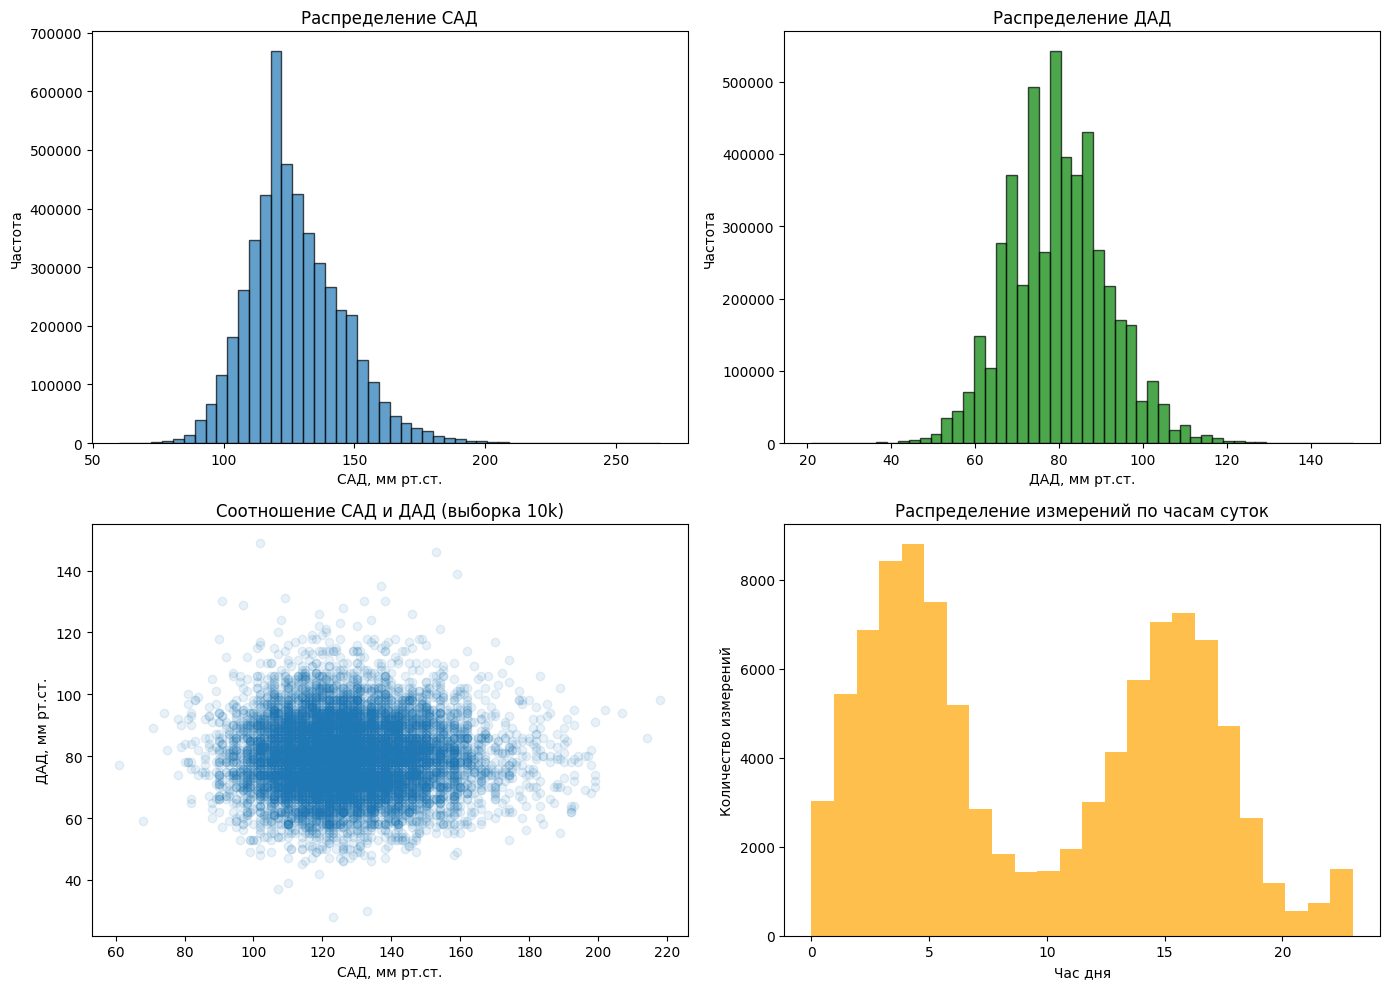

In [46]:
# ============= ЭТАП 5: АНАЛИЗ ПО ГРУППАМ =============

print("\n" + "="*50)
print("ЭТАП 5: АНАЛИЗ ПО ГРУППАМ НАБЛЮДЕНИЯ")
print("="*50)

# Добавляем информацию о группе к первичным данным
primary = primary.merge(
    patient_program[['id пациента', 'группа наблюдения']].drop_duplicates('id пациента'),
    on='id пациента',
    how='left'
)

print("\n1. Распределение групп:")
group_dist = primary['группа наблюдения'].value_counts(dropna=False)
print(group_dist)
print(f"\nВсего пациентов в группах: {group_dist.sum():,}")

print("\n2. Статистика измерений по группам:")
group_stats = primary.groupby('группа наблюдения').agg({
    'id пациента': 'nunique',
    'САД': ['mean', 'std', 'count'],
    'ДАД': ['mean', 'std'],
    'ЧП': ['mean', 'std']
}).round(1)
print(group_stats)

# ============= ЭТАП 6: БАЗОВАЯ ВИЗУАЛИЗАЦИЯ =============

print("\n" + "="*50)
print("ЭТАП 6: БАЗОВАЯ ВИЗУАЛИЗАЦИЯ")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Распределение САД
axes[0, 0].hist(primary['САД'].dropna(), bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Распределение САД')
axes[0, 0].set_xlabel('САД, мм рт.ст.')
axes[0, 0].set_ylabel('Частота')

# 2. Распределение ДАД
axes[0, 1].hist(primary['ДАД'].dropna(), bins=50, alpha=0.7, edgecolor='black', color='green')
axes[0, 1].set_title('Распределение ДАД')
axes[0, 1].set_xlabel('ДАД, мм рт.ст.')
axes[0, 1].set_ylabel('Частота')

# 3. Соотношение САД и ДАД
axes[1, 0].scatter(primary['САД'].sample(10000), primary['ДАД'].sample(10000), alpha=0.1)
axes[1, 0].set_title('Соотношение САД и ДАД (выборка 10k)')
axes[1, 0].set_xlabel('САД, мм рт.ст.')
axes[1, 0].set_ylabel('ДАД, мм рт.ст.')

# 4. Измерения по времени
primary_sample = primary.sample(min(100000, len(primary)))
axes[1, 1].hist(primary_sample['время измерения'].dt.hour.dropna(), bins=24, alpha=0.7, color='orange')
axes[1, 1].set_title('Распределение измерений по часам суток')
axes[1, 1].set_xlabel('Час дня')
axes[1, 1].set_ylabel('Количество измерений')

plt.tight_layout()
plt.savefig('eda_basic_plots.png', dpi=100)
print("\n  Базовые графики сохранены в 'eda_basic_plots.png'")

# ============= ЭТАП 7: КЗС АНАЛИЗ =============

print("\n" + "="*50)
print("ЭТАП 7: АНАЛИЗ КЛИНИЧЕСКИ ЗНАЧИМЫХ СОБЫТИЙ")
print("="*50)

# Топ событий
print("\n1. Топ-10 КЗС:")
top_kzs = kzs['код КЗС'].value_counts().head(10)
print(top_kzs)

# События на пациента
kzs_per_patient = kzs.groupby('id пациента').size()
print(f"\n2. Статистика КЗС на пациента:")
print(f"  Среднее: {kzs_per_patient.mean():.1f}")
print(f"  Медиана: {kzs_per_patient.median():.1f}")
print(f"  Макс: {kzs_per_patient.max():,}")
print(f"  % пациентов с КЗС: {(len(kzs_per_patient) / patient_program['id пациента'].nunique() * 100):.1f}%")

# ============= ЭТАП 8: ТЕРАПИЯ АНАЛИЗ =============

print("\n" + "="*50)
print("ЭТАП 8: АНАЛИЗ ТЕРАПИИ")
print("="*50)

print(f"\n1. Всего записей терапии: {len(therapy):,}")

if 'МНН' in therapy.columns:
    print("\n2. Топ-10 назначаемых МНН:")
    top_mnn = therapy['МНН'].value_counts().head(10)
    print(top_mnn)

print("\n3. Назначения по годам:")
therapy['год_назначения'] = therapy['дата назначения'].dt.year
print(therapy['год_назначения'].value_counts().sort_index())

# ============= ЭТАП 9: СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ =============

print("\n" + "="*50)
print("ЭТАП 9: СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ")
print("="*50)

# Удаляем явные выбросы для сохранения чистой версии
clean_primary = primary[
    ~invalid_sbp & 
    ~invalid_dbp & 
    ~invalid_hr & 
    ~invalid_age &
    ~future_meas
].copy()

print(f"\nИсходный размер primary: {len(primary):,}")
print(f"Размер после удаления выбросов: {len(clean_primary):,}")
print(f"Удалено: {len(primary) - len(clean_primary):,} записей ({(1 - len(clean_primary)/len(primary))*100:.1f}%)")
# Сохраняем для дальнейшего использования
clean_primary.to_csv('primary_clean.csv', index=False)
patient_program.to_csv('patient_program.csv', index=False)
kzs.to_csv('kzs.csv', index=False)
therapy.to_csv('therapy.csv', index=False)

print("\n  Очищенные данные сохранены в формате parquet:")
print("  - primary_clean.parquet")
print("  - patient_program.parquet")
print("  - kzs.parquet")
print("  - therapy.parquet")

# ============= ЭТАП 10: ИТОГОВАЯ ИНФОРМАЦИЯ =============

print("\n" + "="*50)
print("ИТОГОВАЯ ИНФОРМАЦИЯ")
print("="*50)

print(f"""
Статистика по очищенным данным:
- Пациентов всего: {patient_program['id пациента'].nunique():,}
- Медицинских организаций: {mo['id МО'].nunique():,}
- Субъектов РФ: {subjects['id субъекта'].nunique():,}
- Измерений (очищенных): {len(clean_primary):,}
- КЗС: {len(kzs):,}
- Записей терапии: {len(therapy):,}

Диапазон дат измерений:
  с {clean_primary['время измерения'].min()}
  по {clean_primary['время измерения'].max()}

Средние значения (по очищенным):
  САД: {clean_primary['САД'].mean():.1f} мм рт.ст.
  ДАД: {clean_primary['ДАД'].mean():.1f} мм рт.ст.
  ЧП: {clean_primary['ЧП'].mean():.1f} уд/мин
  Возраст: {clean_primary['возраст'].mean():.1f} лет
""")

print("\n✅ Подготовка данных завершена!")